# Demand — rolling statistics EDA

Daily notebook — small experiment, fully reproducible (seed pinned below).

Before any modeling: rolling mean/std and monthly averages to see trend + seasonality.

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)


## Data

In [ ]:
SEED = 1346

rng = np.random.RandomState(SEED)
days = pd.date_range("2023-01-01", periods=730, freq="D")
trend = np.linspace(50, 90, 730)
seasonal = 12 * np.sin(2 * np.pi * np.arange(730) / 7) + 8 * np.sin(2 * np.pi * np.arange(730) / 365)
noise = rng.normal(0, 4, 730)
y = trend + seasonal + noise
df = pd.DataFrame({"date": days, "demand": y.round(1)}).set_index("date")
print("shape:", df.shape)
print(df.head(3).to_string())
print(df.tail(3).to_string())


shape: (730, 1)
            demand
date              
2023-01-01    49.2
2023-01-02    62.1
2023-01-03    61.4
            demand
date              
2024-12-28    78.1
2024-12-29    90.5
2024-12-30    97.9


## Rolling stats

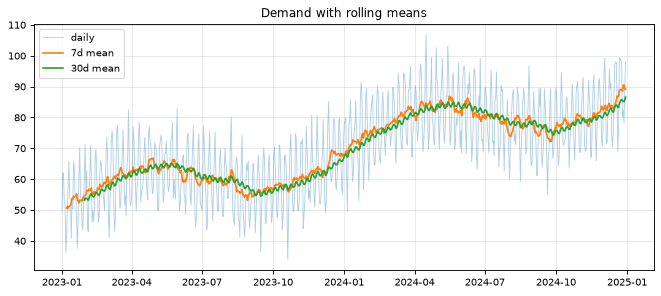

In [ ]:

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df.index, df["demand"], alpha=0.35, lw=0.8, label="daily")
ax.plot(df.index, df["demand"].rolling(7).mean(), label="7d mean")
ax.plot(df.index, df["demand"].rolling(30).mean(), label="30d mean")
ax.legend(); ax.set_title("Demand with rolling means")


## Monthly pattern

date
1     63.6
2     66.9
3     70.6
4     73.9
5     74.1
6     71.0
7     69.7
8     67.3
9     65.5
10    69.0
11    70.6
12    76.1


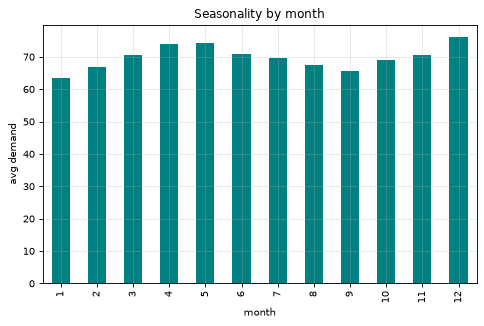

In [ ]:

monthly = df["demand"].groupby(df.index.month).mean()
fig, ax = plt.subplots()
monthly.plot.bar(ax=ax, color="teal")
ax.set_xlabel("month"); ax.set_ylabel("avg demand"); ax.set_title("Seasonality by month")
print(monthly.round(1).to_string())


## Takeaways

- Clear upward trend + weekly cycle; monthly seasonality is mild.
- 7-day rolling mean is the right smoother for the weekly pattern.